# t-SNE + DBSCAN Hyperparameter Tuning

## Objective 

The purpose of this notebook is to find the best t-SNE + DBSCAN clustering solution using the current cohort-scaled dataset.
The analysis follows the general approach :
- Use the Min-Max scaled clustering dataset
- Reduce the data to 2 dimensions using t-SNE
- Use Euclidean distance
- Estimate suitable DBSCAN epsilon values using the k-distance knee method
- Apply DBSCAN using different `Epsilon` and `MinPts` values
- Evaluate every clustering solution using :
    - Silhouette Score : Higher is better
    - Davies-Bouldin Index : Lower is better
    - Calinski-Harabasz Index : Higher is better
- Examine the number of clusters and outliers
- Select the best practical clustering solution

The number of clusters is not fixed in advance. It will be determined by the best-performing hyperparameter combination.

## Import Required Libraries

This section imports the python libraries needed for :
- Loading and working with the dataset
- Running t-SNE
- Running DBSCAN
- Calculating clustering evaluation metrics
- Finding nearest-neighbor distances
- Creating plots
- Saving the results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from kneed import KneeLocator

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## Define Project Paths

This section defines the locations of the data, results and plot folders.

The results and plots folders will be created automatically if they do not already exist.

In [2]:
ROOT_DIR = Path.cwd().parent.parent

DATA_DIR = ROOT_DIR / "results" / "module_2" / "dataset_creation"
RESULTS_DIR = ROOT_DIR / "results" / "module_2" / "3.tsne_dbscan_tuning"
PLOTS_DIR = ROOT_DIR / "plots" / "module_2" / "3.tsne_dbscan_tuning"

RESULTS_DIR.mkdir(parents = True, exist_ok = True)
PLOTS_DIR.mkdir(parents = True, exist_ok = True)

print("Root directory:", ROOT_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Plots directory:", PLOTS_DIR)

Root directory: C:\Users\samsa\Documents\ICU Clustering
Data directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.tsne_dbscan_tuning
Plots directory: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\3.tsne_dbscan_tuning


## Load the Current Cohort-Scaled Dataset

The current cohort-scaled dataset will be loaded in this section. The dataset should contain :
- One row for each patient
- One patient identifier column
- THe clustering features already transformed and Min-Max scaled

Because this dataset is already scaled, Min-Max scaling will not be repeated in this.

In [3]:
DATA_FILE = DATA_DIR / "clustering_dataset_scaled.csv"

df = pd.read_csv(DATA_FILE)
print(f"Shape of the Dataset : {df.shape}")

Shape of the Dataset : (7859, 81)


## Inspect the Dataset

Before running t-SNE and DBSCAN, the dataset is checked to confirm :
- Number of Patients
- Number of Columns
- Column Names
- Missing Values
- Duplicate Patients
- Whether the clustering features are within the expected Min-Max scaled range

In [4]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
df.sample(10)

Number of Rows : 7859
Number of Columns : 81


,patientunitstayid,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
7841,3331171,0.916667,0.0,0.259046,0.071204,0.063745,0.352601,0.060630,0.321429,0.585366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1286,856781,0.402778,1.0,0.292763,0.101032,0.079681,0.381503,0.051181,0.250000,0.536585,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7645,3203499,0.472222,1.0,0.276316,0.096658,0.139442,0.219653,0.000394,0.267857,0.560976,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
282,219082,0.763889,1.0,0.300822,0.105741,0.139442,0.341040,0.009449,0.321429,0.707317,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6862,3001378,0.805556,0.0,0.296546,0.095649,0.087649,0.323699,0.057874,0.392857,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6333,2889886,0.930556,0.0,0.276316,0.096322,0.127490,0.341040,0.085827,0.337500,0.804878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1347,723597,0.708333,1.0,0.288158,0.068850,0.278884,0.456647,0.037008,0.321429,0.682927,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3464,1571488,0.833333,1.0,0.288322,0.071249,0.055777,0.375723,0.046654,0.357143,0.365854,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6899,3130120,0.569444,1.0,0.296546,0.083315,0.071713,0.479769,0.019291,0.250000,0.341463,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7279,3059334,0.541667,1.0,0.296546,0.094416,0.231076,0.369942,0.013780,0.500000,0.219512,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [5]:
COLUMN_NAMES = DATA_DIR / "clustering_feature_names.csv"

print("Column Names :")
features = COLUMN_NAMES.read_text().strip().split(",")

for column in features:
    print(column.strip())

Column Names :
feature_name
age
gender
admissionheight
admissionweight
BUN_min
Hgb_min
WBC x 1000_min
anion gap_min
bicarbonate_min
chloride_min
creatinine_min
glucose_min
lactate_min
platelets x 1000_min
potassium_min
sodium_min
BUN_max
Hgb_max
WBC x 1000_max
anion gap_max
bicarbonate_max
chloride_max
creatinine_max
glucose_max
lactate_max
platelets x 1000_max
potassium_max
sodium_max
BUN_mean
Hgb_mean
WBC x 1000_mean
anion gap_mean
bicarbonate_mean
chloride_mean
creatinine_mean
glucose_mean
lactate_mean
platelets x 1000_mean
potassium_mean
sodium_mean
BUN_std
Hgb_std
WBC x 1000_std
anion gap_std
bicarbonate_std
chloride_std
creatinine_std
glucose_std
lactate_std
platelets x 1000_std
potassium_std
sodium_std
lab_measurement_count
sao2_fpc_1
sao2_fpc_2
sao2_fpc_3
sao2_fpc_4
sao2_fpc_5
sao2_fpc_6
sao2_fpc_7
sao2_fpc_8
heartrate_fpc_1
heartrate_fpc_2
respiration_fpc_1
respiration_fpc_2
respiration_fpc_3
respiration_fpc_4
ethnicity_African American
ethnicity_Asian
ethnicity_Caucasian
ethn

## Check Missing Values

t-SNE and DBSCAN require a complete numerical clustering matrix.

THe final clustering dataset should therefore contain no missing values.

In [6]:
total_missing = df.isna().sum().sum()

print(f"Total Missing Values in the Dataset : {total_missing}")

Total Missing Values in the Dataset : 0


## Define the Patient ID Column

The patient identifier is required for saving the final cluster assignments but it must not be included as an input feature for t-SNE or DBSCAN.

The patient ID column is therefore separated from the clustering features.

In [7]:
ID_COLUMN = "patientunitstayid"

patient_ids = df[ID_COLUMN].copy()

X = df.drop(columns = [ID_COLUMN]).copy()

print(f"Number of Patients : {len(patient_ids)}")
print(f"Number of Clustering Features : {X.shape[1]}")

Number of Patients : 7859
Number of Clustering Features : 80


## Confirm That All Clustering Features Are Numeric

t-SNE requires numerical input.

This check confirms that all columns included in the clustering matrix are numeric.

In [8]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns.tolist()
print(f"Non-Numeric Columns : {non_numeric_columns}")

Non-Numeric Columns : []


## Check Infinite Values

In [9]:
infinite_values = np.isinf(X.to_numpy()).sum()

print("Infinite values:", infinite_values)

Infinite values: 0


## Confirm the Min-Max Scaling

The current clustering dataset has already been Min-Max scaled.

The feature values should therefore be approximately between $0$ and $1$. Small floating-point differences slightly above $1$ may occassionally occur.

In [10]:
minimum_value = X.min().min()
maximum_value = X.max().max()

print("Minimum feature value:", minimum_value)
print("Maximum feature value:", maximum_value)

Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


## Final Dataset Verification

This section summarizes the dataset that will be used for hyperparameter tuning.

The analysis should proceed only when :
- There is one row per patient
- There are no missing values
- There are no infinite values
- All clustering variables are numeric
- The feature matrix is Min-Max scaled

In [11]:
print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("Patients:", X.shape[0])
print("Clustering features:", X.shape[1])
print("Missing values:", X.isna().sum().sum())
print("Infinite values:", np.isinf(X.to_numpy()).sum())
print("Minimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())

print("=" * 60)

DATASET VERIFICATION
Patients: 7859
Clustering features: 80
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


## Define Hyperparameter Values

The following parameters will be investigated.

### t-SNE

The perplexity values will follow the same range used in the earlier
replication analysis.

Fixed t-SNE settings:

- n_components = $2$
- metric = Euclidean

### DBSCAN

The following MinPts values will be evaluated:

$10, 20, 30, ..., 100$

The following epsilon values will be considered:

$1.0, 1.5, 2.0, ..., 7.0$

The k-distance curve will first be used to identify the approximate knee
location. The epsilon grid will then be evaluated in relation to this knee.

In [12]:
min_samples_values = [
    50
]

eps_values = np.arange(
    1.0, 30.5, 0.5
).tolist()

perplexity_values = [
    10, 20, 30, 40, 50,
    60, 70, 80, 90, 100
]

print("MinPts values:")
print(min_samples_values)

print("\nEpsilon values:")
print(eps_values)

print("\nPerplexity values:")
print(perplexity_values)

MinPts values:
[50]

Epsilon values:
[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0]

Perplexity values:
[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


## Generate t-SNE Embeddings

t-SNE will now be applied to the current Min-Max scaled clustering features.

A separate 2-dimensional t-SNE embedding will be created for each perplexity value.

The following settings are kept fixed:
- Number of dimensions = 2
- Distance metric = Euclidean
- Initialization = PCA
- Learning rate = Auto
- Random seed = 42

A fixed random seed is used so that the hyperparameter comparison is
reproducible.

Each t-SNE embedding will also be saved so that it does not need to be
recalculated during DBSCAN tuning.

In [13]:
tsne_embeddings = {}

for perplexity in perplexity_values :
    print("=" * 60)
    print("Running t-SNE with perplexity :", perplexity)
    tsne = TSNE (
        n_components = 2,
        perplexity = perplexity,
        metric = "euclidean",
        init = "pca",
        learning_rate = "auto",
        max_iter = 2000,
        random_state = 42
    )
    embedding = tsne.fit_transform(X)
    tsne_embeddings[perplexity] = embedding
    print(f"Complete Perplexity : {perplexity}")

Running t-SNE with perplexity : 10
Complete Perplexity : 10
Running t-SNE with perplexity : 20
Complete Perplexity : 20
Running t-SNE with perplexity : 30
Complete Perplexity : 30
Running t-SNE with perplexity : 40
Complete Perplexity : 40
Running t-SNE with perplexity : 50
Complete Perplexity : 50
Running t-SNE with perplexity : 60
Complete Perplexity : 60
Running t-SNE with perplexity : 70
Complete Perplexity : 70
Running t-SNE with perplexity : 80
Complete Perplexity : 80
Running t-SNE with perplexity : 90
Complete Perplexity : 90
Running t-SNE with perplexity : 100
Complete Perplexity : 100


#### Observation :

For example :
```
Perplexity = 10
       ↓
t-SNE
       ↓
2-dimensional embedding
```

then :
```
Perplexity = 20
       ↓
t-SNE
       ↓
another 2-dimensional embedding
```

## Check the Generated Embeddings

This section confirms that one t-SNE embedding was successfully generated for every perplexity value.

In [14]:
print(f"Number of t-SNE embeddings : {len(tsne_embeddings)}")

print("Available Perplexities :")
for perplexity in tsne_embeddings:
    print(perplexity, "->", tsne_embeddings[perplexity].shape)

Number of t-SNE embeddings : 10
Available Perplexities :
10 -> (7859, 2)
20 -> (7859, 2)
30 -> (7859, 2)
40 -> (7859, 2)
50 -> (7859, 2)
60 -> (7859, 2)
70 -> (7859, 2)
80 -> (7859, 2)
90 -> (7859, 2)
100 -> (7859, 2)


## Save Each Embeddings 

Each t-SNE embedding is saved as a CSV file.

Saving the embeddings prevents the computationally expensive t-SNE step from having to be repeated if the notebook is restarted.

In [15]:
EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

for perplexity in perplexity_values:

    embedding = tsne_embeddings[perplexity]

    embedding_df = pd.DataFrame(
        embedding,
        columns=["TSNE_1", "TSNE_2"]
    )

    embedding_df.insert(
        0,
        ID_COLUMN,
        patient_ids.reset_index(drop=True)
    )

    file_path = (
        EMBEDDINGS_DIR /
        f"perplexity_{perplexity}.csv"
    )

    embedding_df.to_csv(
        file_path,
        index=False
    )

print("All t-SNE embeddings saved successfully.")
print("Saved in:", EMBEDDINGS_DIR)

All t-SNE embeddings saved successfully.
Saved in: C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.tsne_dbscan_tuning\embeddings


## Important Knee Detection Tool

DBSCAN requires two important parameters :
- `min_samples` : minimum number of nearby points required to form a dense region.
- `eps` : maximum distance used to define neighboring points

For every t-SNE perplexity and MinPts combination, a k-distance curve will be calculated. The knee of this curve provides a data-driven estimate of a suitable epsilon.
The detected knee will then be matched with the predefined epsilon search values from `1.0` to `7.0`

## Calculate k-Distance Knee for Each Parameter Combination

For every :
- t-SNE perplexity
- MinPts value

The distance to the MinPts-th nearest neighbor is calculated.

The distances are sorted to create a k-distance curve.

The knee point of the curve provides the suggested DBSCAN epsilon values.

In [16]:
knee_results = []

for perplexity in perplexity_values :
    print("=" * 60)
    print("Perplexity :", perplexity)
    embedding = tsne_embeddings[perplexity]
    for min_samples in min_samples_values :
        neighbors = NearestNeighbors(
            n_neighbors=min_samples,
            metric="euclidean"
        )
        neighbors.fit(embedding)
        distances,indices = neighbors.kneighbors(embedding)

        # Distance to the furthest neighbor
        k_distances = distances[:,-1]

        # Sort distances from smallest to largest
        k_distances = np.sort(k_distances)

        # Find the knee
        x = np.arange(len(k_distances))
        
        knee = KneeLocator(
            x,
            k_distances,
            curve="convex",
            direction="increasing"
        )
        
        if knee.knee is not None:
            knee_eps = k_distances[knee.knee]
        else:
            knee_eps = np.nan
        
        knee_results.append({
            "Perplexity": perplexity,
            "MinPts": min_samples,
            "Knee_Eps": knee_eps
        })
        
        print(
            "MinPts:",
            min_samples,
            "| Knee eps:",
            round(knee_eps, 3) if not np.isnan(knee_eps) else "Not found"
        )

Perplexity : 10
MinPts: 50 | Knee eps: 13.257
Perplexity : 20
MinPts: 50 | Knee eps: 14.968
Perplexity : 30
MinPts: 50 | Knee eps: 13.302
Perplexity : 40
MinPts: 50 | Knee eps: 12.436
Perplexity : 50
MinPts: 50 | Knee eps: 12.578
Perplexity : 60
MinPts: 50 | Knee eps: 9.066
Perplexity : 70
MinPts: 50 | Knee eps: 13.2
Perplexity : 80
MinPts: 50 | Knee eps: 13.053
Perplexity : 90
MinPts: 50 | Knee eps: 13.042
Perplexity : 100
MinPts: 50 | Knee eps: 11.683


## Review the Detected Knee Values

The detected epsilon knee for every perplexity and MinPts combination is stored in a table.

This allows us to examine how the density structure changes when different t-SNE and DBSCAN settings are used.

In [17]:
knee_df = pd.DataFrame(knee_results)

display(knee_df)

,Perplexity,MinPts,Knee_Eps
0,10,50,13.257404
1,20,50,14.968105
2,30,50,13.301559
3,40,50,12.435874
4,50,50,12.578145
5,60,50,9.066281
6,70,50,13.200170
7,80,50,13.052509
8,90,50,13.041579
9,100,50,11.683071


In [18]:
print("Number of knee estimates:", len(knee_df))

print("\nKnee epsilon summary:")
display(knee_df["Knee_Eps"].describe())

Number of knee estimates: 10

Knee epsilon summary:


count    10.000000
mean     12.658470
std       1.513399
min       9.066281
25%      12.471441
50%      13.047044
75%      13.243096
max      14.968105
Name: Knee_Eps, dtype: float64

In [19]:
knee_file = RESULTS_DIR / "" "dbscan_knee_results.csv"
knee_df.to_csv(knee_file, index=False)
print("Knee results saved successfully.")

Knee results saved successfully.


## Create the DBSCAN Candidate Table

The detected knee value for each t-SNE perplexity and MinPts combination is used to choose a small set of nearby epsilon values.

For each knee :
- the closest epsilon value is selected
- one epsilon value below is included
- one epsilon value above is included

This avoids testing every possible epsilon value and keeps the DBSCAN search focused around the k-distance knee.

In [20]:
epsilon_candidates = []

for _, row in knee_df.iterrows():

    perplexity = int(row["Perplexity"])
    min_samples = int(row["MinPts"])
    knee_eps = row["Knee_Eps"]

    # Find the epsilon value closest to the knee
    closest_index = np.argmin(
        np.abs(np.array(eps_values) - knee_eps)
    )

    # Select one epsilon below, closest epsilon, and one above
    candidate_indices = [
        closest_index - 1,
        closest_index,
        closest_index + 1
    ]

    for index in candidate_indices:

        if 0 <= index < len(eps_values):

            epsilon_candidates.append({
                "Perplexity": perplexity,
                "MinPts": min_samples,
                "Knee_Eps": knee_eps,
                "Eps": eps_values[index]
            })

## Convert Candidates into a DataFrame

The selected DBSCAN parameter combinations are converted into a table.

Duplicate combinations are removed before running DBSCAN.

In [21]:
candidate_df = pd.DataFrame(epsilon_candidates)

candidate_df = candidate_df.drop_duplicates(
    subset=["Perplexity", "MinPts", "Eps"]
)

candidate_df = candidate_df.reset_index(drop=True)

print("Number of DBSCAN combinations to test:", len(candidate_df))

display(candidate_df.head(20))

Number of DBSCAN combinations to test: 30


,Perplexity,MinPts,Knee_Eps,Eps
0,10,50,13.257404,13.0
1,10,50,13.257404,13.5
2,10,50,13.257404,14.0
3,20,50,14.968105,14.5
4,20,50,14.968105,15.0
5,20,50,14.968105,15.5
6,30,50,13.301559,13.0
7,30,50,13.301559,13.5
8,30,50,13.301559,14.0
9,40,50,12.435874,12.0


## Check Candidate Epsilon Range

In [22]:
print("Minimum candidate epsilon:")
print(candidate_df["Eps"].min())

print("\nMaximum candidate epsilon:")
print(candidate_df["Eps"].max())

print("\nCandidate epsilon summary:")
print(candidate_df["Eps"].describe())

Minimum candidate epsilon:
8.5

Maximum candidate epsilon:
15.5

Candidate epsilon summary:
count    30.000000
mean     12.650000
std       1.565523
min       8.500000
25%      12.125000
50%      13.000000
75%      13.500000
max      15.500000
Name: Eps, dtype: float64


## Mark Candidates Within the Original Epsilon Range

A separate column is added to identify solutions with epsilon between 1 and 7.

This allows the final analysis to compare:

- the best overall solution for the current cohort
- the best solution within the earlier epsilon range

In [23]:
candidate_df["Within_1_to_7"] = candidate_df["Eps"] <= 7.0

display(candidate_df.head(20))

,Perplexity,MinPts,Knee_Eps,Eps,Within_1_to_7
0,10,50,13.257404,13.0,False
1,10,50,13.257404,13.5,False
2,10,50,13.257404,14.0,False
3,20,50,14.968105,14.5,False
4,20,50,14.968105,15.0,False
5,20,50,14.968105,15.5,False
6,30,50,13.301559,13.0,False
7,30,50,13.301559,13.5,False
8,30,50,13.301559,14.0,False
9,40,50,12.435874,12.0,False


## Run DBSCAN Hyperparameter Tuning

DBSCAN is applied to every knee-guided parameter combination.

For every clustering solution, the following information is recorded:

- Perplexity
- MinPts
- Epsilon
- Knee epsilon
- Number of clusters
- Number of outliers
- Outlier percentage
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

Only valid clustering solutions containing at least two clusters are
evaluated using the internal clustering metrics.

In [24]:
dbscan_results = []

for i, row in candidate_df.iterrows():

    perplexity = int(row["Perplexity"])
    min_samples = int(row["MinPts"])
    eps = row["Eps"]
    knee_eps = row["Knee_Eps"]

    embedding = tsne_embeddings[perplexity]

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean"
    )

    labels = dbscan.fit_predict(embedding)

    # Number of clusters, excluding noise label -1
    cluster_labels = set(labels)
    cluster_labels.discard(-1)

    n_clusters = len(cluster_labels)

    # Number of outliers
    n_outliers = np.sum(labels == -1)

    outlier_percentage = (
        n_outliers / len(labels)
    ) * 100

    # Default metric values
    silhouette = np.nan
    dbi = np.nan
    chi = np.nan

    # Calculate metrics only when at least 2 clusters exist
    if n_clusters >= 2:

        non_noise_mask = labels != -1

        clean_embedding = embedding[non_noise_mask]
        clean_labels = labels[non_noise_mask]

        # Make sure at least two clusters remain
        if len(np.unique(clean_labels)) >= 2:

            silhouette = silhouette_score(
                clean_embedding,
                clean_labels
            )

            dbi = davies_bouldin_score(
                clean_embedding,
                clean_labels
            )

            chi = calinski_harabasz_score(
                clean_embedding,
                clean_labels
            )

    dbscan_results.append({
        "Perplexity": perplexity,
        "MinPts": min_samples,
        "Knee_Eps": knee_eps,
        "Eps": eps,
        "Clusters": n_clusters,
        "Outliers": n_outliers,
        "Outlier_Percentage": outlier_percentage,
        "Silhouette": silhouette,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

    print(
        f"{i + 1}/{len(candidate_df)} | "
        f"Perplexity={perplexity} | "
        f"MinPts={min_samples} | "
        f"Eps={eps} | "
        f"Clusters={n_clusters} | "
        f"Outliers={outlier_percentage:.2f}%"
    )

1/30 | Perplexity=10 | MinPts=50 | Eps=13.0 | Clusters=15 | Outliers=2.40%
2/30 | Perplexity=10 | MinPts=50 | Eps=13.5 | Clusters=14 | Outliers=2.18%
3/30 | Perplexity=10 | MinPts=50 | Eps=14.0 | Clusters=11 | Outliers=1.93%
4/30 | Perplexity=20 | MinPts=50 | Eps=14.5 | Clusters=8 | Outliers=1.09%
5/30 | Perplexity=20 | MinPts=50 | Eps=15.0 | Clusters=8 | Outliers=1.06%
6/30 | Perplexity=20 | MinPts=50 | Eps=15.5 | Clusters=8 | Outliers=0.95%
7/30 | Perplexity=30 | MinPts=50 | Eps=13.0 | Clusters=10 | Outliers=0.62%
8/30 | Perplexity=30 | MinPts=50 | Eps=13.5 | Clusters=10 | Outliers=0.62%
9/30 | Perplexity=30 | MinPts=50 | Eps=14.0 | Clusters=10 | Outliers=0.00%
10/30 | Perplexity=40 | MinPts=50 | Eps=12.0 | Clusters=10 | Outliers=0.67%
11/30 | Perplexity=40 | MinPts=50 | Eps=12.5 | Clusters=10 | Outliers=0.48%
12/30 | Perplexity=40 | MinPts=50 | Eps=13.0 | Clusters=10 | Outliers=0.00%
13/30 | Perplexity=50 | MinPts=50 | Eps=12.0 | Clusters=8 | Outliers=0.00%
14/30 | Perplexity=50 | M

## Create the Hyperparameter Results Table

In [25]:
results_df = pd.DataFrame(dbscan_results)

print("Total models evaluated:", len(results_df))

display(results_df.head(20))

Total models evaluated: 30


,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,10,50,13.257404,13.0,15,189,2.404886,0.155074,0.616576,1013.117528
1,10,50,13.257404,13.5,14,171,2.175849,0.180982,0.629187,1091.754139
2,10,50,13.257404,14.0,11,152,1.934088,-0.063615,0.669805,412.321268
3,20,50,14.968105,14.5,8,86,1.094287,0.166224,0.663196,1174.997679
4,20,50,14.968105,15.0,8,83,1.056114,0.165974,0.663032,1175.607262
5,20,50,14.968105,15.5,8,75,0.954320,0.165303,0.662599,1177.219222
6,30,50,13.301559,13.0,10,49,0.623489,0.277691,0.640586,2155.610617
7,30,50,13.301559,13.5,10,49,0.623489,0.277691,0.640586,2155.610617
8,30,50,13.301559,14.0,10,0,0.000000,0.273109,0.640352,2163.358166
9,40,50,12.435874,12.0,10,53,0.674386,0.482283,0.583298,6296.325285


## Keeping Validate Clustering Solutions

Only clustering solutions containing at least two clusters and valid internal
evaluation scores are retained for model comparison.

In [26]:
valid_results_df = results_df[
    results_df["Clusters"] >= 2
].copy()

valid_results_df = valid_results_df.dropna(
    subset=[
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
)

valid_results_df = valid_results_df.reset_index(drop=True)

print("Valid clustering solutions:", len(valid_results_df))

display(valid_results_df.head())

Valid clustering solutions: 30


,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,10,50,13.257404,13.0,15,189,2.404886,0.155074,0.616576,1013.117528
1,10,50,13.257404,13.5,14,171,2.175849,0.180982,0.629187,1091.754139
2,10,50,13.257404,14.0,11,152,1.934088,-0.063615,0.669805,412.321268
3,20,50,14.968105,14.5,8,86,1.094287,0.166224,0.663196,1174.997679
4,20,50,14.968105,15.0,8,83,1.056114,0.165974,0.663032,1175.607262


## Save All Hyperparameter Results

In [27]:
results_file = RESULTS_DIR / "tsne_dbscan_hyperparameter_results.csv"

results_df.to_csv(
    results_file,
    index=False
)

print("Hyperparameter results saved successfully.")

Hyperparameter results saved successfully.


## Rank the Valid CLustering Solutions

The valid DBSCAN solutions are ranked using the primary internal
evaluation criteria.

The ranking priority is:

1. Higher Silhouette Score
2. Lower Davies-Bouldin Index
3. Higher Calinski-Harabasz Index

The number of clusters and outlier percentage are retained for practical
evaluation after the internal metrics have been considered.

In [28]:
ranked_results_df = valid_results_df.sort_values(
    by=[
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ],
    ascending=[
        False,
        True,
        False
    ]
).reset_index(drop=True)

display(ranked_results_df.head(20))

,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,60,50,9.066281,9.5,9,37,0.470798,0.533421,0.598041,8606.257750
1,60,50,9.066281,8.5,12,37,0.470798,0.530562,0.535919,11262.159746
2,100,50,11.683071,11.0,7,1,0.012724,0.499989,0.652616,8335.668250
3,100,50,11.683071,11.5,7,0,0.000000,0.499835,0.652989,8326.946488
4,40,50,12.435874,12.0,10,53,0.674386,0.482283,0.583298,6296.325285
5,40,50,12.435874,12.5,10,38,0.483522,0.480244,0.585877,6230.068707
6,40,50,12.435874,13.0,10,0,0.000000,0.475824,0.593600,6086.441697
7,90,50,13.041579,12.5,6,0,0.000000,0.473340,0.585358,7436.101369
8,60,50,9.066281,9.0,11,37,0.470798,0.470665,0.584056,7837.143000
9,70,50,13.200170,12.5,8,0,0.000000,0.470107,0.548613,6696.846037


## Display the Top 10 Solutions Clearly

The ten highest-ranked t-SNE + DBSCAN solutions are displayed for
closer comparison.

In [29]:
top_10 = ranked_results_df.head(10)

columns_to_show = [
    "Perplexity",
    "MinPts",
    "Knee_Eps",
    "Eps",
    "Clusters",
    "Outliers",
    "Outlier_Percentage",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

display(top_10[columns_to_show])

,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,60,50,9.066281,9.5,9,37,0.470798,0.533421,0.598041,8606.257750
1,60,50,9.066281,8.5,12,37,0.470798,0.530562,0.535919,11262.159746
2,100,50,11.683071,11.0,7,1,0.012724,0.499989,0.652616,8335.668250
3,100,50,11.683071,11.5,7,0,0.000000,0.499835,0.652989,8326.946488
4,40,50,12.435874,12.0,10,53,0.674386,0.482283,0.583298,6296.325285
5,40,50,12.435874,12.5,10,38,0.483522,0.480244,0.585877,6230.068707
6,40,50,12.435874,13.0,10,0,0.000000,0.475824,0.593600,6086.441697
7,90,50,13.041579,12.5,6,0,0.000000,0.473340,0.585358,7436.101369
8,60,50,9.066281,9.0,11,37,0.470798,0.470665,0.584056,7837.143000
9,70,50,13.200170,12.5,8,0,0.000000,0.470107,0.548613,6696.846037


In [30]:
top_10_display = top_10[columns_to_show].copy()

top_10_display["Knee_Eps"] = top_10_display["Knee_Eps"].round(3)
top_10_display["Outlier_Percentage"] = top_10_display["Outlier_Percentage"].round(2)
top_10_display["Silhouette"] = top_10_display["Silhouette"].round(4)
top_10_display["Davies_Bouldin"] = top_10_display["Davies_Bouldin"].round(4)
top_10_display["Calinski_Harabasz"] = top_10_display["Calinski_Harabasz"].round(2)

display(top_10_display)

,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,60,50,9.066,9.5,9,37,0.47,0.5334,0.5980,8606.26
1,60,50,9.066,8.5,12,37,0.47,0.5306,0.5359,11262.16
2,100,50,11.683,11.0,7,1,0.01,0.5000,0.6526,8335.67
3,100,50,11.683,11.5,7,0,0.00,0.4998,0.6530,8326.95
4,40,50,12.436,12.0,10,53,0.67,0.4823,0.5833,6296.33
5,40,50,12.436,12.5,10,38,0.48,0.4802,0.5859,6230.07
6,40,50,12.436,13.0,10,0,0.00,0.4758,0.5936,6086.44
7,90,50,13.042,12.5,6,0,0.00,0.4733,0.5854,7436.10
8,60,50,9.066,9.0,11,37,0.47,0.4707,0.5841,7837.14
9,70,50,13.200,12.5,8,0,0.00,0.4701,0.5486,6696.85


## Save the Ranked Results

In [31]:
ranked_file = RESULTS_DIR / "tsne_dbscan_ranked_results.csv"

ranked_results_df.to_csv(
    ranked_file,
    index=False
)

print("Ranked results saved successfully.")

Ranked results saved successfully.


## Identify the Best Internal-Metric Solution

The first model in the ranked results table represents the strongest
solution according to the primary ranking criteria:

- maximum Silhouette Score
- minimum Davies-Bouldin Index
- maximum Calinski-Harabasz Index

In [32]:
best_internal_model = ranked_results_df.iloc[0]

print("=" * 60)
print("BEST MODEL BASED ON INTERNAL METRICS")
print("=" * 60)

print("Perplexity:", int(best_internal_model["Perplexity"]))
print("MinPts:", int(best_internal_model["MinPts"]))
print("Knee epsilon:", round(best_internal_model["Knee_Eps"], 3))
print("DBSCAN epsilon:", best_internal_model["Eps"])

print("\nNumber of clusters:", int(best_internal_model["Clusters"]))
print("Number of outliers:", int(best_internal_model["Outliers"]))
print(
    "Outlier percentage:",
    round(best_internal_model["Outlier_Percentage"], 2),
    "%"
)

print("\nSilhouette Score:", round(best_internal_model["Silhouette"], 4))
print(
    "Davies-Bouldin Index:",
    round(best_internal_model["Davies_Bouldin"], 4)
)
print(
    "Calinski-Harabasz Index:",
    round(best_internal_model["Calinski_Harabasz"], 2)
)

print("=" * 60)

BEST MODEL BASED ON INTERNAL METRICS
Perplexity: 60
MinPts: 50
Knee epsilon: 9.066
DBSCAN epsilon: 9.5

Number of clusters: 9
Number of outliers: 37
Outlier percentage: 0.47 %

Silhouette Score: 0.5334
Davies-Bouldin Index: 0.598
Calinski-Harabasz Index: 8606.26


## Recreate the Best Clustering Solution

The highest-ranked hyperparameter combination is fitted again so that
its cluster assignments can be examined in detail.

In [33]:
best_perplexity = int(best_internal_model["Perplexity"])
best_min_samples = int(best_internal_model["MinPts"])
best_eps = float(best_internal_model["Eps"])

best_embedding = tsne_embeddings[best_perplexity]

best_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="euclidean"
)

best_labels = best_dbscan.fit_predict(best_embedding)

print("Best clustering recreated successfully.")

Best clustering recreated successfully.


## Examine Cluster Sizes

The number of patients assigned to each cluster is examined.

DBSCAN assigns the label -1 to observations considered noise or outliers.

In [34]:
cluster_sizes = pd.Series(best_labels).value_counts().sort_index()

cluster_size_df = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Patients": cluster_sizes.values
})

cluster_size_df["Percentage"] = (
    cluster_size_df["Patients"] / len(best_labels)
) * 100

display(cluster_size_df)

,Cluster,Patients,Percentage
0,-1,37,0.470798
1,0,385,4.898842
2,1,1720,21.885736
3,2,2118,26.949994
4,3,2195,27.929762
5,4,168,2.137677
6,5,625,7.952666
7,6,246,3.130169
8,7,122,1.552360
9,8,243,3.091996


## Separate Noise from Actual Clusters

In [35]:
actual_clusters_df = cluster_size_df[
    cluster_size_df["Cluster"] != -1
].copy()

noise_df = cluster_size_df[
    cluster_size_df["Cluster"] == -1
].copy()

print("Number of actual clusters:", len(actual_clusters_df))

print(
    "Smallest cluster size:",
    actual_clusters_df["Patients"].min()
)

print(
    "Largest cluster size:",
    actual_clusters_df["Patients"].max()
)

if len(noise_df) > 0:
    print(
        "Noise patients:",
        int(noise_df["Patients"].iloc[0])
    )

    print(
        "Noise percentage:",
        round(noise_df["Percentage"].iloc[0], 2),
        "%"
    )
else:
    print("Noise patients: 0")

Number of actual clusters: 9
Smallest cluster size: 122
Largest cluster size: 2195
Noise patients: 37
Noise percentage: 0.47 %


## Evaluate Cluster Sizes for the Top Candidate Models

Internal metrics are the primary selection criteria.

However, the top candidate solutions are also checked for very small
clusters because extremely small groups may represent unstable or
clinically unhelpful clustering solutions.

In [36]:
top_candidates = ranked_results_df.head(20).copy()

minimum_cluster_sizes = []

for _, row in top_candidates.iterrows():

    perplexity = int(row["Perplexity"])
    min_samples = int(row["MinPts"])
    eps = float(row["Eps"])

    embedding = tsne_embeddings[perplexity]

    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean"
    ).fit_predict(embedding)

    cluster_counts = pd.Series(labels).value_counts()

    # Remove the noise cluster
    cluster_counts = cluster_counts[
        cluster_counts.index != -1
    ]

    minimum_cluster_sizes.append(
        cluster_counts.min()
    )

top_candidates["Smallest_Cluster"] = minimum_cluster_sizes

In [37]:
candidate_columns = [
    "Perplexity",
    "MinPts",
    "Eps",
    "Clusters",
    "Outlier_Percentage",
    "Smallest_Cluster",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

display(
    top_candidates[candidate_columns]
)

,Perplexity,MinPts,Eps,Clusters,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,60,50,9.5,9,0.470798,122,0.533421,0.598041,8606.257750
1,60,50,8.5,12,0.470798,94,0.530562,0.535919,11262.159746
2,100,50,11.0,7,0.012724,95,0.499989,0.652616,8335.668250
3,100,50,11.5,7,0.000000,95,0.499835,0.652989,8326.946488
4,40,50,12.0,10,0.674386,98,0.482283,0.583298,6296.325285
5,40,50,12.5,10,0.483522,98,0.480244,0.585877,6230.068707
6,40,50,13.0,10,0.000000,98,0.475824,0.593600,6086.441697
7,90,50,12.5,6,0.000000,95,0.473340,0.585358,7436.101369
8,60,50,9.0,11,0.470798,94,0.470665,0.584056,7837.143000
9,70,50,12.5,8,0.000000,119,0.470107,0.548613,6696.846037


## Applying Simple Practical Conditions

After ranking models by the internal evaluation metrics, basic practical
conditions are applied.

A candidate solution is retained when:

- it contains at least two clusters
- no more than 20 percent of patients are classified as outliers
- the smallest identified cluster contains at least 30 patients

These conditions prevent an apparently strong internal score from being
selected when the clustering solution contains excessive noise or
extremely small clusters.

In [38]:
practical_candidates = top_candidates[
    (top_candidates["Outlier_Percentage"] <= 20) &
    (top_candidates["Smallest_Cluster"] >= 30)
].copy()

practical_candidates = practical_candidates.reset_index(drop=True)

print(
    "Number of practical candidates:",
    len(practical_candidates)
)

display(
    practical_candidates[candidate_columns]
)

Number of practical candidates: 20


,Perplexity,MinPts,Eps,Clusters,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,60,50,9.5,9,0.470798,122,0.533421,0.598041,8606.257750
1,60,50,8.5,12,0.470798,94,0.530562,0.535919,11262.159746
2,100,50,11.0,7,0.012724,95,0.499989,0.652616,8335.668250
3,100,50,11.5,7,0.000000,95,0.499835,0.652989,8326.946488
4,40,50,12.0,10,0.674386,98,0.482283,0.583298,6296.325285
5,40,50,12.5,10,0.483522,98,0.480244,0.585877,6230.068707
6,40,50,13.0,10,0.000000,98,0.475824,0.593600,6086.441697
7,90,50,12.5,6,0.000000,95,0.473340,0.585358,7436.101369
8,60,50,9.0,11,0.470798,94,0.470665,0.584056,7837.143000
9,70,50,12.5,8,0.000000,119,0.470107,0.548613,6696.846037


## Select Best Pracitcal Model

In [39]:
if len(practical_candidates) > 0:

    final_model = practical_candidates.iloc[0]

    print("=" * 60)
    print("FINAL T-SNE + DBSCAN CANDIDATE")
    print("=" * 60)

    print("Perplexity:", int(final_model["Perplexity"]))
    print("MinPts:", int(final_model["MinPts"]))
    print("Epsilon:", final_model["Eps"])

    print("\nNumber of clusters:", int(final_model["Clusters"]))
    print(
        "Outlier percentage:",
        round(final_model["Outlier_Percentage"], 2),
        "%"
    )
    print(
        "Smallest cluster:",
        int(final_model["Smallest_Cluster"])
    )

    print(
        "\nSilhouette Score:",
        round(final_model["Silhouette"], 4)
    )
    print(
        "Davies-Bouldin Index:",
        round(final_model["Davies_Bouldin"], 4)
    )
    print(
        "Calinski-Harabasz Index:",
        round(final_model["Calinski_Harabasz"], 2)
    )

    print("=" * 60)

else:

    print(
        "No candidate met all practical conditions."
    )

FINAL T-SNE + DBSCAN CANDIDATE
Perplexity: 60
MinPts: 50
Epsilon: 9.5

Number of clusters: 9
Outlier percentage: 0.47 %
Smallest cluster: 122

Silhouette Score: 0.5334
Davies-Bouldin Index: 0.598
Calinski-Harabasz Index: 8606.26


In [40]:
original_eps_results = ranked_results_df[
    ranked_results_df["Eps"] <= 7
].copy()

print(
    "Valid solutions with epsilon <= 7:",
    len(original_eps_results)
)

display(
    original_eps_results[
        columns_to_show
    ].head(10)
)

Valid solutions with epsilon <= 7: 0


,Perplexity,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz


## Refit the Final Model

In [41]:
final_perplexity = int(final_model["Perplexity"])
final_min_samples = int(final_model["MinPts"])
final_eps = float(final_model["Eps"])

final_embedding = tsne_embeddings[final_perplexity]

final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    metric="euclidean"
)

final_labels = final_dbscan.fit_predict(
    final_embedding
)

print("Final DBSCAN model fitted successfully.")

Final DBSCAN model fitted successfully.


## Plot the Final Clustering Solution

The final cluster assignments are visualized on the selected t-SNE
embedding.

The cluster label -1 represents patients classified as noise by DBSCAN.

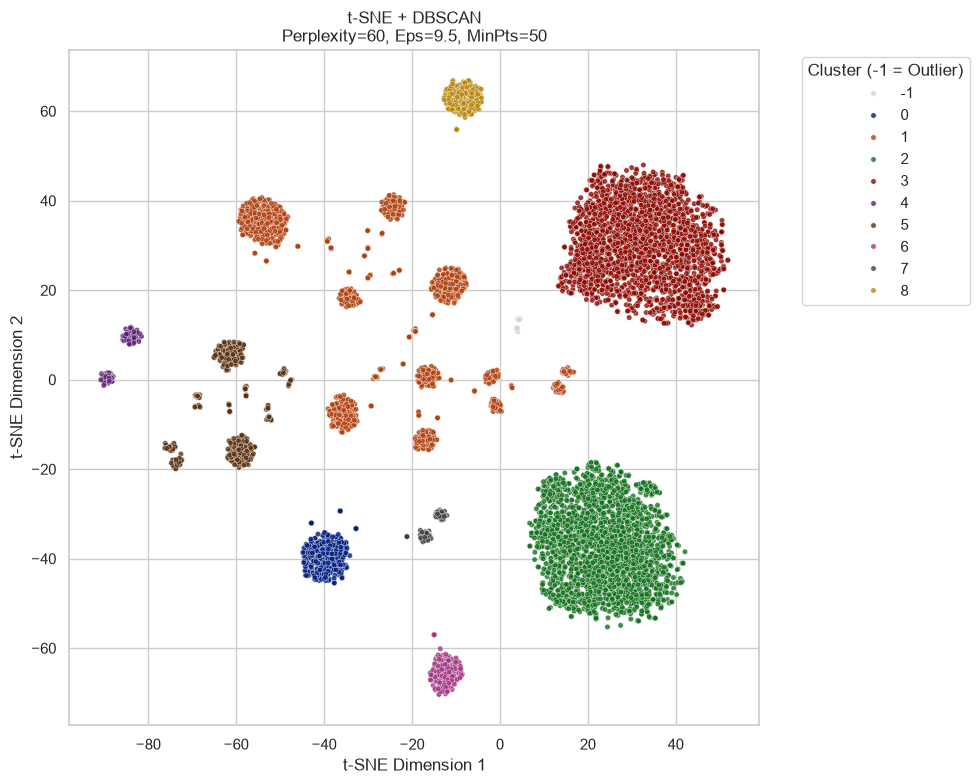

In [42]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Build a color palette mapping clusters to dark colors and outliers (-1) to grey
unique_clusters = sorted([c for c in np.unique(final_labels) if c != -1])
palette = {
    c: color for c, color in zip(unique_clusters, sns.color_palette("dark", len(unique_clusters)))
}
palette[-1] = "lightgrey"

# Plot embeddings
sns.scatterplot(
    x=final_embedding[:, 0],
    y=final_embedding[:, 1],
    hue=final_labels,
    palette=palette,
    s=15,
    alpha=0.8,
)

# Labels, title, and legend formatting
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    f"t-SNE + DBSCAN\n"
    f"Perplexity={final_perplexity}, Eps={final_eps}, MinPts={final_min_samples}"
)
plt.legend(title="Cluster (-1 = Outlier)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

## Save the Final Cluster Assignments

The patient identifier, final t-SNE coordinates, and DBSCAN cluster
assignment are saved for later cluster characterization and clinical
analysis.

In [43]:
final_clusters_df = pd.DataFrame({
    ID_COLUMN: patient_ids.reset_index(drop=True),
    "TSNE_1": final_embedding[:, 0],
    "TSNE_2": final_embedding[:, 1],
    "Cluster": final_labels
})

final_cluster_file = (
    RESULTS_DIR / "final_tsne_dbscan_clusters.csv"
)

final_clusters_df.to_csv(
    final_cluster_file,
    index=False
)

print("Final cluster assignments saved successfully.")

display(final_clusters_df.head())

Final cluster assignments saved successfully.


,patientunitstayid,TSNE_1,TSNE_2,Cluster
0,151900,-41.305496,-37.181965,0
1,165269,-53.146446,26.543024,1
2,179269,27.727377,-31.084177,2
3,172764,32.751060,-28.937243,2
4,215156,14.346917,-33.792847,2


## Save the Final Parameter Summary

In [44]:
final_summary = pd.DataFrame({
    "Parameter": [
        "Perplexity",
        "Epsilon",
        "MinPts",
        "Number of Clusters",
        "Number of Outliers",
        "Outlier Percentage",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "Value": [
        final_perplexity,
        final_eps,
        final_min_samples,
        int(final_model["Clusters"]),
        int(np.sum(final_labels == -1)),
        final_model["Outlier_Percentage"],
        final_model["Silhouette"],
        final_model["Davies_Bouldin"],
        final_model["Calinski_Harabasz"]
    ]
})

display(final_summary)

,Parameter,Value
0,Perplexity,60.000000
1,Epsilon,9.500000
2,MinPts,50.000000
3,Number of Clusters,9.000000
4,Number of Outliers,37.000000
5,Outlier Percentage,0.470798
6,Silhouette Score,0.533421
7,Davies-Bouldin Index,0.598041
8,Calinski-Harabasz Index,8606.257750


In [45]:
summary_file = (
    RESULTS_DIR / "final_tsne_dbscan_parameters.csv"
)

final_summary.to_csv(
    summary_file,
    index=False
)

print("Final parameter summary saved successfully.")

Final parameter summary saved successfully.
